<a href="https://colab.research.google.com/github/LeandroLDA/ColabNotebooks/blob/EmCriacao/TACTD_Avaliacao_Final_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <font color="blue"> MBA em Ciência de Dados</font>
# <font color="blue">Técnicas Avançadas de Captura e Tratamento de Dados</font>

## <font color="blue">Avaliação Final - 2025</font>
**Luis Gustavo Nonato** e **Moacir Antonelli Ponti**<br>

**Cemeai - ICMC/USP São Carlos**

A avaliação vale 10 pontos e está dividida em duas partes, cada uma valendo 5.0 pontos.


<font color='red'>**ATENÇÃO:** Quando terminar a avaliação, você deve fazer um "upload" do notebook no _moodle_</font>.

## Parte 1

Os exercícios da Parte 1 fazem uso da coleção de documentos contida no pacote de dados do <font color='blue'> scikit </font> learn. A célula abaixo carrega a base de dados de documentos associados a quatro categorias diferentes. A célula também carrega os pacotes necessários para resolver os exercícios da Parte 1.

In [200]:
from sklearn.datasets import fetch_20newsgroups
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

nltk.download('punkt_tab')
nltk.download('stopwords')

category = ['sci.space', 'rec.autos', 'comp.graphics', 'misc.forsale']

stop_words = stopwords.words('english')

newsgroups = fetch_20newsgroups(subset='train', categories=category)
docs = newsgroups.data # docs é uma lista onde cada elemento é um documento

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### Questão 1 (2.5 pontos)
Construa um DataFrame <font color='blue'>pandas</font> onde as colunas correspondem aos documentos e as linhas às palavras que aparecem nos documentos. As palavras a serem inseridas nas linhas do DataFrame devem satisfazer:
- ser formada por dois ou mais caracteres do alfabeto (palavras com caracteres numéricos ou símbolos devem ser desconsideradas)
- não deve ser uma stopword (use a lista de stopwords do inglês)
- deve estar lexicamente normalizada

Cada palavra lexicamente normalizada deve aparecer apenas uma vez no DataFrame. Além disso, as entradas do DataFrame devem ser binárias, ou seja, se a palavra que aparece na linha $i$ está presente no documento representado pela coluna $j$, então a posição $(i,j)$ do DataFrame deve conter o valor 1, sendo 0 caso contrário.

Imprima as três palavras que aparecem em mais documentos. Em quantos documentos tais palavras aparecem?

In [201]:
lista_de_docs = []
lista_unificada = []

for conteudo in docs:
  palavras = nltk.word_tokenize(conteudo)
  filtro = [w.lower() for w in palavras if w.isalpha() and len(w) != 1]
  Sws = [w for w in filtro if w not in stop_words]
  stemizadas = [PorterStemmer().stem(w) for w in Sws]
  lista_de_docs.append(stemizadas)
  lista_unificada.extend(stemizadas)

In [202]:
unicas_lista_unificada = set(list(lista_unificada))

In [203]:
print(len(lista_de_docs))
print(len(lista_unificada))
print(len(unicas_lista_unificada))

2356
273980
18822


In [204]:
matriz = np.zeros((len(unicas_lista_unificada), len(lista_de_docs)), dtype=int)
matriz.shape

(18822, 2356)

In [205]:
indice_palavras = {palavra: i for i, palavra in enumerate(unicas_lista_unificada)}

for doc_id, palavra_doc in enumerate(lista_de_docs):
  for palavra in palavra_doc:
    pal_id = indice_palavras[palavra]
    matriz[pal_id, doc_id] = 1

In [206]:
colunas = [f"doc_{i}" for i in range(len(lista_de_docs))]
linhas = list(unicas_lista_unificada)

df_ex1 = pd.DataFrame(matriz, index = linhas, columns= colunas)

df_ex1.head()

,doc_0,doc_1,doc_2,doc_3,doc_4,doc_5,doc_6,doc_7,doc_8,doc_9,...,doc_2346,doc_2347,doc_2348,doc_2349,doc_2350,doc_2351,doc_2352,doc_2353,doc_2354,doc_2355
southi,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
father,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
multisync,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
vox,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
asi,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [207]:
soma_palavras = df_ex1.sum(axis = 1)
top_3 = soma_palavras.sort_values(ascending=False)
print(f"As três palavras mais usadas são: {top_3[:3].index.values} com {top_3[:3].values} ocorrências, respectivamente")

As três palavras mais usadas são: ['subject' 'line' 'organ'] com [2356 2354 2278] ocorrências, respectivamente


### Questão 2 (2.5 pontos)
Considere o DataFrame construído na questão 1.
- Remova do DataFrame as palavras que aparecem apenas em 1 documento e imprima quantas palavras foram removidas.
- Considerando cada coluna (documento) do DataFrame resultante da operação anterior com um ponto em um espaço de alta dimensão, calcule as direções principais dos pontos.
- Faça o gráfico da curva das variâncias explicadas e veja como elas tendem a zero.
- Qual o número mínimo de direções principais necessárias para capturar 80% da variância explicada?
- Projete os pontos nas duas direções principais com maior variância e faça um "scatter plot" dos pontos projetados.  

*Remova do DataFrame as palavras que aparecem apenas em 1 documento e imprima quantas palavras foram removidas.*

In [208]:
total_por_palavra = df_ex1.sum(axis = 1)

filtro = total_por_palavra[total_por_palavra <=1].index.tolist()


In [209]:
df_ex2 = df_ex1.drop(filtro, axis=0, inplace=False)


In [210]:
print(f"No total, foram excluidas {df_ex1.shape[0] - df_ex2.shape[0]} palavras")

No total, foram excluidas 8794 palavras


*Considerando cada coluna (documento) do DataFrame resultante da operação anterior com um ponto em um espaço de alta dimensão, calcule as direções principais dos pontos.*

In [211]:
df_ex2_transposto = df_ex2.T # Deixo essa linha separada para nâo transpor o df novamente por acidente e comprometer a análise

In [212]:
pca_obj=PCA(svd_solver='full')
df_ex2_pca = pca_obj.fit(df_ex2_transposto)


In [213]:
print(f"O número de dimensões principais encontradas pelo PCA é: {df_ex2_pca.n_components_}")

O número de dimensões principais encontradas pelo PCA é: 2356


*Faça o gráfico da curva das variâncias explicadas e veja como elas tendem a zero.*

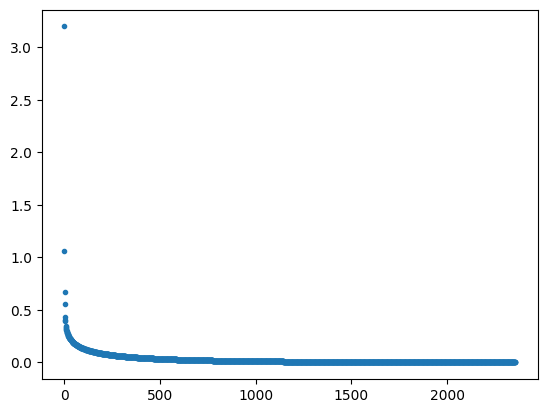

In [214]:
import matplotlib.pyplot as plt
plt.plot(df_ex2_pca.explained_variance_, '.')

*Qual o número mínimo de direções principais necessárias para capturar 80% da variância explicada?*


In [215]:
porcentagem = 0.0
componentes = 0
for i in range(df_ex2_pca.explained_variance_ratio_.shape[0]):
    porcentagem += df_ex2_pca.explained_variance_ratio_[i]
    if porcentagem >= 0.80:
        componentes = i+1
        break

print("Numero de componentes para capturar 80% da variância:",componentes)
print(f"Porcentagem exata da informacao capturada: {round(porcentagem*100,3)}%")

Numero de componentes para capturar 80% da variância: 591
Porcentagem exata da informacao capturada: 80.041%


*Projete os pontos nas duas direções principais com maior variância e faça um "scatter plot" dos pontos projetados.*

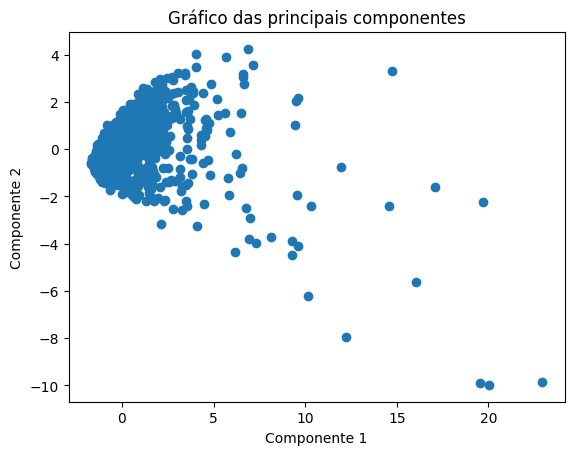

In [216]:
df_ex2_transformado = df_ex2_pca.transform(df_ex2_transposto)
dir_principais = df_ex2_transformado[:, 0:2]

plt.scatter(dir_principais[:,0],dir_principais[:,1])
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.title('Gráfico das principais componentes')
plt.show()

---
## Parte 2

### Questão 3  (2.5 pontos)

Carregue a base de dados California Housing conforme o código abaixo, e realize as seguintes tarefas:

1. Particione o conjunto aleatoriamente, sendo 10% reservado para teste
2. Remova outliers considerando as colunas em `check_outliers`, removendo as linhas com o critério de 3*IQR. Exiba quantos outliers foram removidos para cada coluna.
3. Normalize as colunas em `normalize` utilizando MinMaxScaler, para o intervalo entre 0 e 1.

Para as operações 2 e 3 acima, trate de forma adequada o processamento no conjunto de treinamento e teste.


In [217]:
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import KBinsDiscretizer, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from lightgbm import LGBMRegressor
import pandas as pd
import math

housing = fetch_california_housing(as_frame=True)
df = housing.frame
print(df.columns)
numeric_features = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

check_outliers = ['AveRooms', 'AveBedrms']
normalize = ['AveRooms', 'AveBedrms', 'Latitude', 'Longitude']

target = df["MedHouseVal"]


Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')


*Particione o conjunto aleatoriamente, sendo 10% reservado para teste*

In [218]:
# Separando preditoras e target
x = df.drop("MedHouseVal", axis = 1)
y = df["MedHouseVal"]

In [219]:
x_treino, x_teste, y_treino, y_teste = train_test_split(x, y, test_size = 0.1, random_state = 42)
print(x_treino.shape[0], x_teste.shape[0])

18576 2064


*Remova outliers considerando as colunas em check_outliers, removendo as linhas com o critério de 3*IQR. Exiba quantos outliers foram removidos para cada coluna.*

In [220]:
num_outliers = {}

for var in check_outliers:
        Q1 = x_treino[var].quantile(0.25)
        Q3 = x_treino[var].quantile(0.75)
        IQR = Q3 - Q1
        factor = 3
        out_inf = Q1 - (IQR * factor)
        out_sup = Q3 + (IQR * factor)

        indices_inliers_treino = x_treino.loc[(x_treino[var] >= out_inf) & (x_treino[var] <= out_sup)].index

        num_outliers[var] = x_treino.shape[0] - len(indices_inliers_treino)
        # = contagem_out

        x_treino = x_treino.loc[indices_inliers_treino]
        y_treino = y_treino.loc[indices_inliers_treino]

        indices_inliers_teste = x_teste.loc[(x_teste[var] >= out_inf) & (x_teste[var] <= out_sup)].index

        x_teste = x_teste.loc[indices_inliers_teste]
        y_teste = y_teste.loc[indices_inliers_teste]

for col, count in num_outliers.items():
     print(f"Foram removidos {count} outliers da coluna {col}")


Foram removidos 160 outliers da coluna AveRooms
Foram removidos 501 outliers da coluna AveBedrms


*Normalize as colunas em normalize utilizando MinMaxScaler, para o intervalo entre 0 e 1.*

In [247]:
nao_normalizar = [col for col in x_treino.columns if col not in normalize]

scaler = MinMaxScaler()

x_treino_norm_subset_array = scaler.fit_transform(x_treino[normalize])
x_teste_norm_subset_array = scaler.transform(x_teste[normalize])

x_treino_nao_norm_subset_df = x_treino[nao_normalizar]
x_teste_nao_norm_subset_df = x_teste[nao_normalizar]

x_treino_norm_subset_df = pd.DataFrame(x_treino_norm_subset_array, index=x_treino.index, columns=normalize)
x_teste_norm_subset_df = pd.DataFrame(x_teste_norm_subset_array, index=x_teste.index, columns=normalize)

x_treino_final = pd.concat([x_treino_nao_norm_subset_df, x_treino_norm_subset_df], axis=1)
x_teste_final = pd.concat([x_teste_nao_norm_subset_df, x_teste_norm_subset_df], axis=1)

x_treino_final = x_treino_final[x_treino.columns]
x_teste_final = x_teste_final[x_teste.columns]

print("\nShape do treino final:", x_treino_final.shape)
print("Shape do teste final:", x_teste_final.shape)
print("Shape do y_treino final:", y_treino.shape)
print("Shape do y_teste final:", y_teste.shape)
print(f"\n Variáveis normalizadas:{normalize}\n")
x_treino_final.sample(5)


Shape do treino final: (17915, 8)
Shape do teste final: (1988, 8)
Shape do y_treino final: (17915,)
Shape do y_teste final: (1988,)

 Variáveis normalizadas:['AveRooms', 'AveBedrms', 'Latitude', 'Longitude']



,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
16229,3.5703,43.0,0.398107,0.282614,721.0,2.253125,0.576596,0.308163
10164,4.4375,24.0,0.507957,0.567439,625.0,2.717391,0.142553,0.652041
10862,5.0956,21.0,0.509766,0.483072,2266.0,3.608280,0.122340,0.661224
12193,2.5395,23.0,0.434583,0.630489,3405.0,2.520355,0.115957,0.714286
332,2.1500,47.0,0.260227,0.384634,327.0,2.386861,0.552128,0.222449


### Questão 4 (2,5 pontos)

Utilize o dataframe processado da questão 3.

1. Utilize o `KBinsDiscretizer` para discretizar em 5 bins utilizando `encode='ordinal'`, `strategy='quantile'` as variáveis contidas na lista `distretize`.
2. Treine um regressor utilizando LightGBM (LGBMRegressor) com seus hiperparametros padrão para predizer a coluna `MedHouseVal` a partir das demais colunas processadas anteriormente
3. Calcule o RMSE (Root Mean Squared Error) do conjunto de treinamento e de teste, e exiba esses erros.

Realize o processamento/tratamento adequado considerando as partições de treinamento e teste.


In [221]:
discretize = ['MedInc', 'HouseAge', 'Population', 'AveOccup']

*1 - Utilize o KBinsDiscretizer para discretizar em 5 bins utilizando encode='ordinal', strategy='quantile' as variáveis contidas na lista distretize.*

In [222]:
discretizador = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile', subsample=None, random_state=42)

In [248]:
print(x_treino_final.shape, x_teste_final.shape) # Me certificando de que as colunas normalizadas e não normalizadas foram concatenadas

(17915, 8) (1988, 8)


In [224]:
x_treino_para_disc = x_treino_final[discretize]
discretizador.fit(x_treino_para_disc)
x_treino_disc = discretizador.transform(x_treino_para_disc)

/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 1 are removed. Consider decreasing the number of bins.
  warnings.warn(


In [225]:
x_teste_para_disc = x_teste_final[discretize]
x_teste_disc = discretizador.transform(x_teste_para_disc)

In [226]:
for i, coluna in enumerate(discretize):   # Substituindo as colunas originais pela versão discretizada
    x_treino_final[coluna] = x_treino_disc[:, i]
    x_teste_final[coluna] = x_teste_disc[:, i]

In [251]:
print(x_treino_final.shape, x_teste_final.shape) # novamente, me certificando da forma dos conjuntos

(17915, 8) (1988, 8)


*2 - Treine um regressor utilizando LightGBM (LGBMRegressor) com seus hiperparametros padrão para predizer a coluna MedHouseVal a partir das demais colunas processadas anteriormente*

In [229]:
regressor = LGBMRegressor()

In [252]:
regressor.fit(x_treino_final, y_treino)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002078 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1837
[LightGBM] [Info] Number of data points in the train set: 17915, number of used features: 8
[LightGBM] [Info] Start training from score 2.086033


LGBMRegressor()

In [253]:
y_treino_predito = regressor.predict(x_treino_final)
y_teste_predito = regressor.predict(x_teste_final)

In [254]:
rmse_treino = np.sqrt(mean_squared_error(y_treino,y_treino_predito))
rmse_teste = np.sqrt(mean_squared_error(y_teste,y_teste_predito))

In [255]:
print(f"RMSE no conjunto de treinamento: {rmse_treino:.2f}")
print(f"RMSE no conjunto de teste: {rmse_teste:.2f}")

RMSE no conjunto de treinamento: 0.39
RMSE no conjunto de teste: 0.44
